**This notebook represents a classic Single-Cell RNA-Sequencing (scRNA-seq) preprocessing pipeline. It uses Scanpy, the industry-standard Python library for analyzing single-cell gene expression data.**

**AIM** : For PHASE_1 is to take raw, messy genomic data, clean out the biological errors, and mathematically transform it so it is ready for machine learning algorithms.

In [2]:
!pip install scanpy -q    ##Installs the Scanpy library into your Google Colab environment , -q hides the loading bars .


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 196.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 213.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 181.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 243.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 943.2 kB/s eta 0:00:00


In [3]:
import scanpy as sc        ## core lib scanpy and numpy
import numpy as np
from google.colab import drive   ## connecting colab with google drive   ,
# ques . why connecting to drive ??
## since our data set is pretty massive so avoid crashing and reuploading process we are connecting to the colab , also colab provides temprory storage , we r also connecting it for permanent storage .

In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Unzip the file directly in your Google Drive
!mkdir -p "/content/drive/MyDrive/Genomics_Project/Unzipped_Data"
!unzip "/content/drive/MyDrive/Cytotrace.zip" -d "/content/drive/MyDrive/Genomics_Project/Unzipped_Data"   ### these commands like mkdir and unzip creates a folder unzipped_data and store zip data there .

print("Unzipping complete!")

Archive:  /content/drive/MyDrive/Cytotrace.zip
replace /content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE102066_34.h5ad? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE103633_39.h5ad? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE106587_41.h5ad? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE107122_32.h5ad? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE107910_40.h5ad? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE109774_24.h5ad? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE109774_25.h5ad? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE36552_18.h5ad? [y]es, [n]o, [A]ll, [N]one

In [6]:
file_path = '/content/drive/MyDrive/Genomics_Project/Unzipped_Data/GSE103633_39.h5ad'

**.h5ad** is the standard file format for AnnData (Annotated Data), which Scanpy uses

In [7]:
# 2. Memory-Efficient Loading
print("Loading data in backed mode to save RAM...")
adata_backed = sc.read_h5ad(file_path, backed='r')
print(f"Original massive dataset size: {adata_backed.n_obs} cells.")

Loading data in backed mode to save RAM...
Original massive dataset size: 6000 cells.


 By passing **backed='r'** (read-only), Scanpy connects to the file on the hard drive without loading the massive matrix into your active RAM. It prevents Colab from crashing due to memory limits

In [8]:
import os       ## available .h5ad files

data_dir = '/content/drive/MyDrive/Genomics_Project/Unzipped_Data'
h5ad_files = [f for f in os.listdir(data_dir) if f.endswith('.h5ad')]

if h5ad_files:
    print('Available .h5ad files:')
    for f in h5ad_files:
        print(f)
else:
    print('No .h5ad files found in the directory.')

Available .h5ad files:
GSE102066_34.h5ad
GSE103633_39.h5ad
GSE106587_41.h5ad
GSE107122_32.h5ad
GSE107910_40.h5ad
GSE109774_24.h5ad
GSE109774_25.h5ad
GSE36552_18.h5ad
GSE45719_28.h5ad
GSE52529_15.h5ad
GSE59114_0.h5ad
GSE52583_21.h5ad
GSE52583_29.h5ad
GSE60783_10.h5ad
GSE64447_33.h5ad
GSE67123_6.h5ad
GSE67602_11.h5ad
GSE70245_12.h5ad
GSE69761_30.h5ad
GSE74767_1.h5ad
GSE74767_2.h5ad
GSE75330_35.h5ad
GSE75330_36.h5ad
GSE75748_14.h5ad
GSE76408_23.h5ad
GSE85066_16.h5ad
GSE86146_19.h5ad
GSE87375_37.h5ad
GSE87375_38.h5ad
GSE90047_13.h5ad
GSE92332_26.h5ad
GSE90860_3.h5ad
GSE92332_31.h5ad
GSE93421_17.h5ad
GSE94641_9.h5ad
GSE95753_4.h5ad
GSE95753_5.h5ad
GSE97391_22.h5ad
GSE97391_27.h5ad
GSE98451_7.h5ad
GSE98664_20.h5ad
GSE99933_8.h5ad


In [9]:
# 3. Smart Downsampling
# Randomly sample 25,000 cells to bring into active RAM for analysis
n_cells_to_sample = 25000
if adata_backed.n_obs > n_cells_to_sample:
    # Get random indices and sort them (required for backed h5ad slicing)
    indices = np.random.choice(adata_backed.n_obs, size=n_cells_to_sample, replace=False) #---> THIS PROMPT    ## If the dataset is larger than 25,000 cells, it randomly selects 25,000 index numbers.
    indices.sort()
    # Pull only the selected cells into active memory
    adata = adata_backed[indices].to_memory()  #----> THIS PROMPT ## It slices the dataset on the hard drive using those random indices, and brings only that subset into active RAM for fast computation.
else:
    adata = adata_backed.to_memory()

# Close the heavy disk file to free up system resources
adata_backed.file.close()
print(f"Working dataset loaded: {adata.n_obs} cells and {adata.n_vars} genes.")

Working dataset loaded: 6000 cells and 27483 genes.


In [10]:
# 4. Biological Quality Control (QC)   #-----> This section removes "garbage" data (PHYSICAL MISTAKE) caused by errors during the physical sequencing process in the lab.
print("Starting Quality Control filtering...")

# Filter out empty droplets (cells with barely any genes) and useless genes
sc.pp.filter_cells(adata, min_genes=200)    ## Drops any "cell" that expressed fewer than 200 genes. These are usually empty droplets of water that didn't actually contain a cell.
sc.pp.filter_genes(adata, min_cells=3)      ## Drops any gene that was found in fewer than 3 cells. These are too rare to be mathematically useful.

# Calculate the percentage of mitochondrial genes
# A high MT percentage means the cell was dying/bursting before sequencing
adata.var['mt'] = adata.var_names.str.startswith('MT-')  #---> Flags all mitochondrial genes (genes starting with "MT-"). In single-cell RNA sequencing, the MT- prefix is used as a health meter or a distress signal for the cell.
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Filter out dying cells (where more than 10% of their genes are mitochondrial)
adata = adata[adata.obs.pct_counts_mt < 10, :]

print(f"Final clean dataset size after QC: {adata.n_obs} cells and {adata.n_vars} genes.")

Starting Quality Control filtering...
Final clean dataset size after QC: 6000 cells and 24803 genes.


In [11]:
# 1. Save a backup of the raw, clean counts (Standard clinical research practice)
adata.raw = adata

In [12]:
# 2. Normalize the data (Industry standard is 10,000 counts per cell)
print("Normalizing cell counts...")
sc.pp.normalize_total(adata, target_sum=1e4)    ## 1e4 is 10000

Normalizing cell counts...


In [13]:
# 3. Log-transform the data (Prepares the math for Machine Learning)
print("Log-transforming data...")
sc.pp.log1p(adata)

Log-transforming data...


In [14]:
# 4. Identify Highly Variable Genes (HVGs)
print("Hunting for the most important genes...")
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

Hunting for the most important genes...


Plotting Highly Variable Genes...


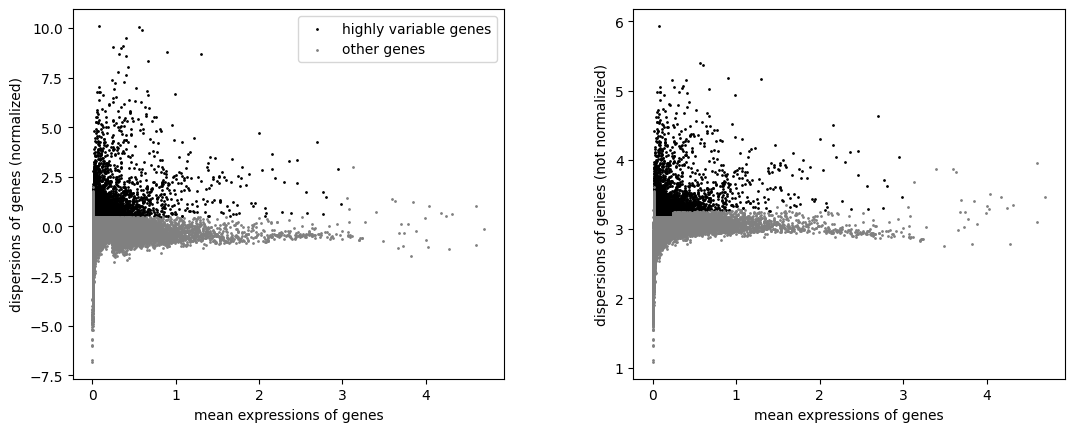

In [15]:
# 5. Visualize the "Signal vs. Noise"
print("Plotting Highly Variable Genes...")
sc.pl.highly_variable_genes(adata)

In [16]:
# 6. Filter the massive matrix down to ONLY the highly variable genes
adata = adata[:, adata.var.highly_variable]

print(f"Phase 1 Complete! Final size ready for processing: {adata.n_obs} cells and {adata.n_vars} genes.")

Phase 1 Complete! Final size ready for processing: 6000 cells and 5209 genes.


In [17]:
print("1. Running Principal Component Analysis (PCA)...")
sc.tl.pca(adata, svd_solver='arpack')

1. Running Principal Component Analysis (PCA)...


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


   -> Plotting PCA Variance to justify our dimensionality choice...


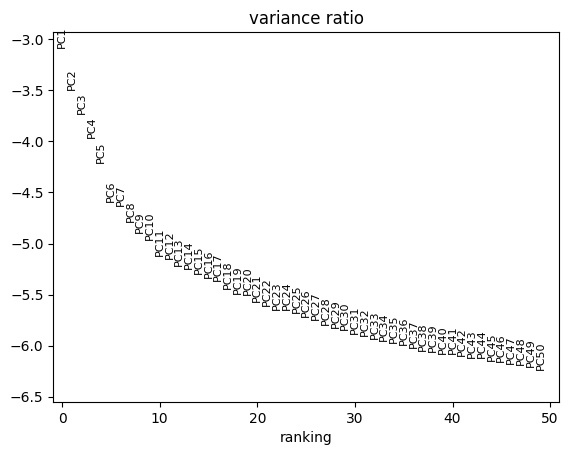

In [18]:
print("   -> Plotting PCA Variance to justify our dimensionality choice...")
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)


In [19]:
print("\n2. Computing the mathematical Neighborhood Graph...")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)


2. Computing the mathematical Neighborhood Graph...


In [20]:
print("3. Generating the 2D UMAP embedding...")
sc.tl.umap(adata, min_dist=0.3)

3. Generating the 2D UMAP embedding...


In [21]:
print("4. Running Leiden Clustering algorithm (resolution=0.5)...")
!pip install leidenalg -q
sc.tl.leiden(adata, resolution=0.5)

4. Running Leiden Clustering algorithm (resolution=0.5)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 38.9 MB/s eta 0:00:00


/tmp/ipykernel_3614/4288036399.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


In [22]:
num_clusters = adata.obs['leiden'].nunique()
print(f"   -> SUCCESS: The AI identified {num_clusters} distinct neural clusters!")

   -> SUCCESS: The AI identified 14 distinct neural clusters!



5. Plotting and saving the Human Cerebral Cortex Map...


/tmp/ipykernel_3614/3016914152.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


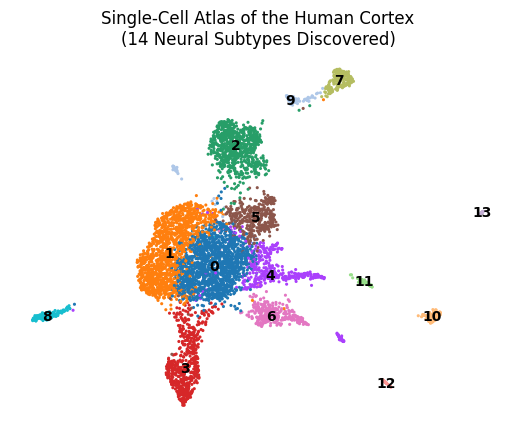

In [23]:
print("\n5. Plotting and saving the Human Cerebral Cortex Map...")
sc.pl.umap(
    adata,
    color='leiden',
    title=f'Single-Cell Atlas of the Human Cortex\n({num_clusters} Neural Subtypes Discovered)',
    frameon=False,          # Removes the ugly box around the plot for a modern look
    legend_loc='on data',   # Puts the cluster numbers directly ON the clusters
    save='_human_cortex_map.pdf' # Automatically saves a high-res PDF to your Colab folder!
)

In [24]:
print("1. Running statistical tests to find Marker Genes for all clusters...")
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

1. Running statistical tests to find Marker Genes for all clusters...



2. Generating Dot Plot of top marker genes...


/tmp/ipykernel_3614/2620141406.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_genes_groups_dotplot(


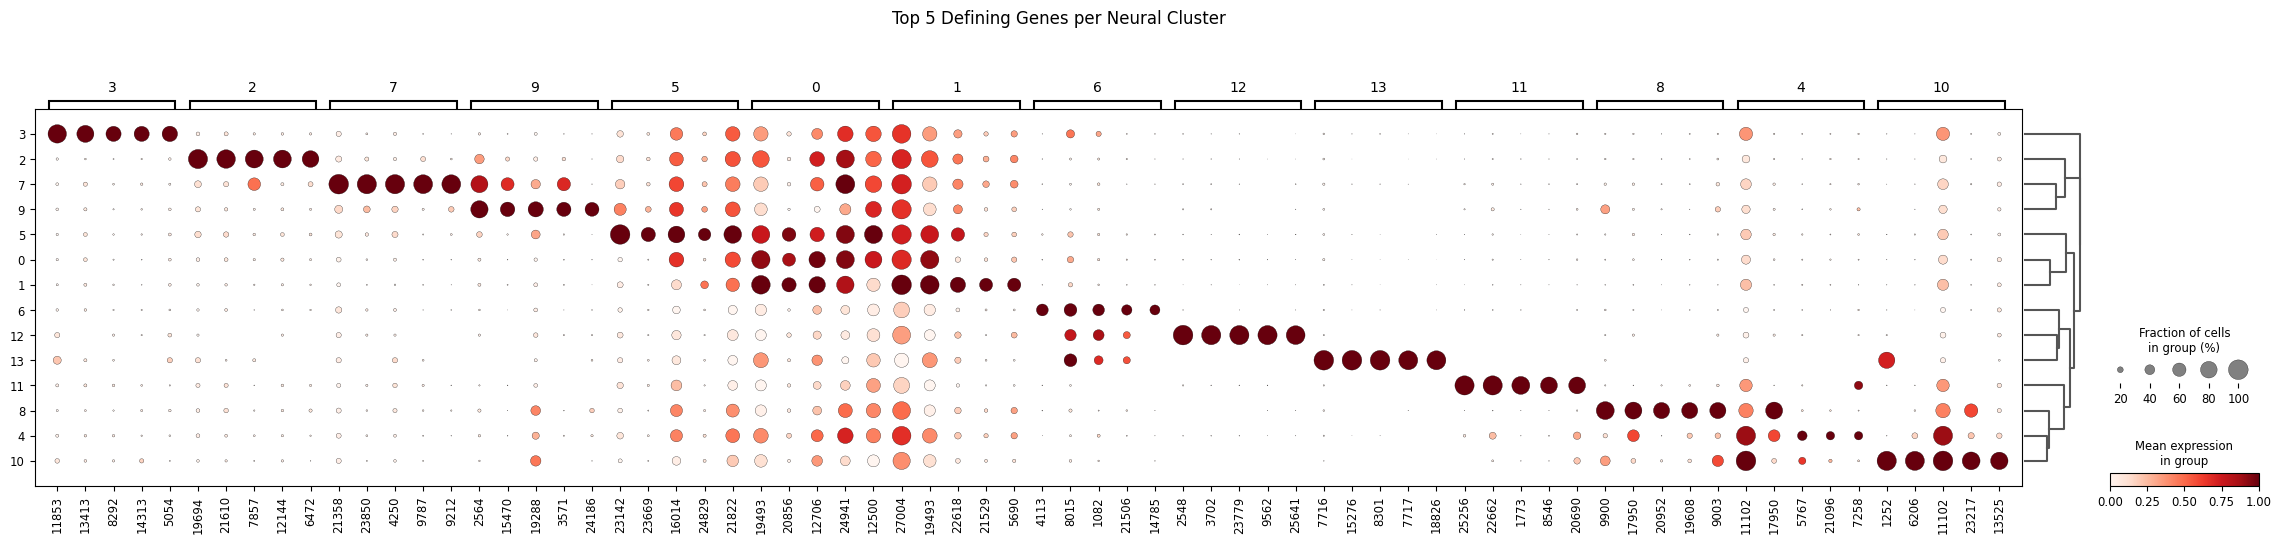

In [25]:
print("\n2. Generating Dot Plot of top marker genes...")
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    standard_scale='var', # Scales the colors beautifully
    title="Top 5 Defining Genes per Neural Cluster",
    save='_top_markers_dotplot.pdf'
)

In [26]:
plasticity_markers = [
    'BDNF',   # Brain-Derived Neurotrophic Factor (Master regulator of plasticity)
    'GAP43',  # Growth Associated Protein 43 (Axonal regeneration)
    'NTRK2'   # The receptor for BDNF
]

# Check which of these markers actually survived our Highly Variable Gene filter in Phase 1
available_markers = [gene for gene in plasticity_markers if gene in adata.var_names]

if available_markers:
    print(f"\n3. Plotting Neuroplasticity Markers: {available_markers}")
    # We will overlay the expression of these healing genes directly onto your UMAP
    sc.pl.umap(
        adata,
        color=available_markers,
        color_map='magma',     # 'magma' gives a brilliant dark-to-bright-yellow heat map
        frameon=False,
        save='_neuroplasticity_map.pdf'
    )
else:
    print("\n3. None of the specific plasticity markers were kept as Highly Variable Genes.")
    print("   (This happens often! We can query standard Neuron markers like 'SNAP25' next).")


3. None of the specific plasticity markers were kept as Highly Variable Genes.
   (This happens often! We can query standard Neuron markers like 'SNAP25' next).
